# Two Dimensional Coded Aperture System

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve, gaussian_filter

#generates a random coded aperture mask with specified size and density
def generate_mask(size, density):
    #- size: Tuple of (height, width) for the mask size.
    #- density: Fraction of open regions (1s) in the mask.
    #output:
    #- mask: 2D binary array of size `size`.
    np.random.seed(0)
    mask = np.random.choice([0, 1], size=size, p=[1 - density, density])  #random binary mask
    return mask

#calculate the shadow on the detector based on the coded mask and source angle
def compute_shadow(mask, source_angle, height, detector_size, pixel_size):
    #- mask: 2D coded aperture mask (binary array).
    #- source_angle: (theta_x, theta_y) in radians.
    #- height: Distance between mask and detector.
    #- detector_size: (width, height) of the detector in pixels.
    #- pixel_size: Physical size of one detector pixel.
    #output:
    #- shadow: 2D array representing the shadow pattern on the detector.
    theta_x, theta_y = source_angle  #extracting the angles

    #calculating the shadow shifts on the detector due to the source angle
    delta_x = int(round(height * np.tan(theta_x) / pixel_size))
    delta_y = int(round(height * np.tan(theta_y) / pixel_size))

    #creating a zero-initialized detector of the specified size
    det_h, det_w = detector_size
    detector = np.zeros((det_h, det_w))

    #extracting dimensions and centers of the mask and detector
    mask_h, mask_w = mask.shape
    mask_center = (mask_h // 2, mask_w // 2)
    det_center = (det_h // 2, det_w // 2)

    #calculating the overlap between the shifted mask shadow and detector
    shadow_x_min = max(det_center[1] - mask_center[1] + delta_x, 0)
    shadow_x_max = min(det_center[1] + mask_center[1] + delta_x, det_w)
    shadow_y_min = max(det_center[0] - mask_center[0] + delta_y, 0)
    shadow_y_max = min(det_center[0] + mask_center[0] + delta_y, det_h)

    mask_x_min = max(mask_center[1] - det_center[1] - delta_x, 0)
    mask_x_max = mask_x_min + (shadow_x_max - shadow_x_min)
    mask_y_min = max(mask_center[0] - det_center[0] - delta_y, 0)
    mask_y_max = mask_y_min + (shadow_y_max - shadow_y_min)

    #conditional statement to check if shadow fits within the detector bounds,we apply the mask pattern
    if shadow_x_max > shadow_x_min and shadow_y_max > shadow_y_min:
        detector[shadow_y_min:shadow_y_max, shadow_x_min:shadow_x_max] = mask[
            mask_y_min:mask_y_max, mask_x_min:mask_x_max
        ]

    return detector

#defining a function for Richardson-Lucy deconvolution, iteratively sharpening the observed shadow
def richardson_lucy_deconvolution_2d(observed, psf, epsilon=1e-5, max_iter=50):
    #- observed: Observed signal
    #- psf: Point Spread Function
    #- epsilon: Small value to avoid division by zero
    #- max_iter: Maximum number of iterations

    #initializing with a uniform estimate as the beginning guess
    F = np.full_like(observed, np.mean(observed))

    for _ in range(max_iter):
        #convolving the current estimate with the PSF
        G = convolve(F, psf, mode='constant', cval=0.0)

        #calculating the ratio of the observed data to the estimate
        C = observed / (G + epsilon)

        #updating the estimate value with a correction factor
        correction = convolve(C, np.flip(np.flip(psf, axis=0), axis=1), mode='constant', cval=0.0)
        F = F * correction

        #in case the correction factor converges, stop the process
        if np.max(np.abs(1 - C)) < epsilon:
            break

    return F

def visualize(mask, shadow, deconvolved, deconvolved_smoothed):
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    titles = ['Coded Aperture', 'Shadow Pattern', 'Deconvolved Source', 'Smoothed Deconvolved']
    images = [mask, shadow, deconvolved, deconvolved_smoothed]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='viridis')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

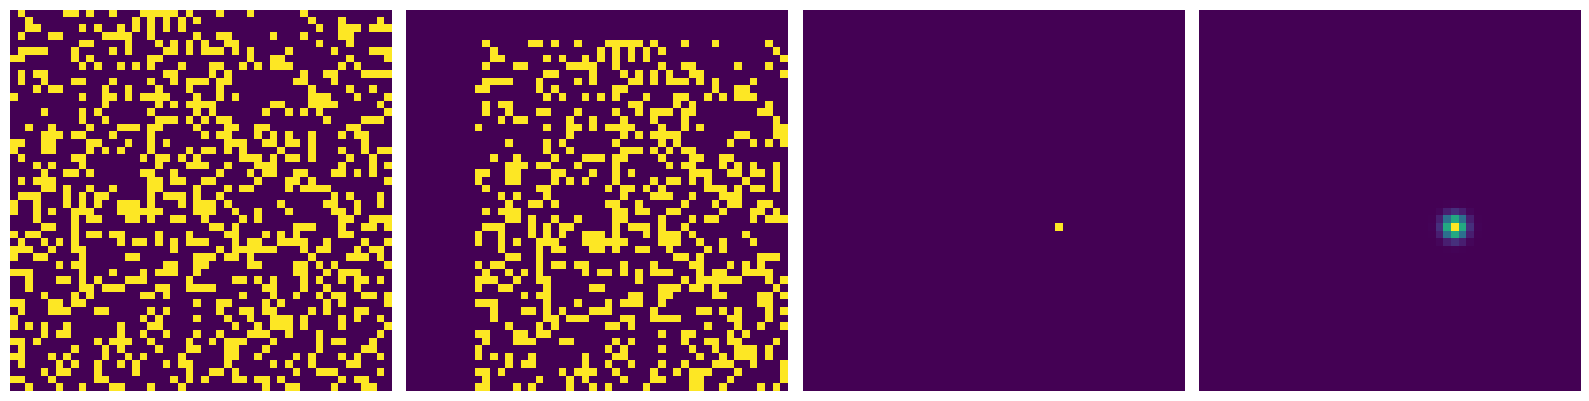

In [3]:
mask_size = (50, 50)       #coded aperture mask size
density = 0.3              #amount of open regions in the mask
detector_size = (50, 50)   #detector dimensions
height = 50.0              #distance from the mask to the detector
pixel_size = 1.0           #size of a single detector pixel
source_angle = (np.radians(10), np.radians(5))  #angles of the light source
epsilon = 1e-5             #convergence threshold for deconvolution
max_iter = 50              #maximum number of iterations for deconvolution

mask = generate_mask(mask_size, density)
shadow = compute_shadow(mask, source_angle, height, detector_size, pixel_size)
deconvolved_source = richardson_lucy_deconvolution_2d(shadow, mask, epsilon, max_iter)
deconvolved_source_smoothed = gaussian_filter(deconvolved_source, sigma=1)

visualize(mask, shadow, deconvolved_source, deconvolved_source_smoothed)